<a href="https://colab.research.google.com/github/uavinash15/DataScience-/blob/main/Notebooks/Assignments/MULTIPLE_LINEAR_REGRESSION_TOYOTA_CORELLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Multiple linear regression analysis to predict the price of Toyota corolla**

In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.Exploratory Data Analysis, Visualizations, Summary statistics, preprocesssing the data**

In [ ]:
#Loading the dataset into a DataFrame
car=pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [ ]:
car

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [ ]:
car.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
car.dtypes

,0
Price,int64
Age_08_04,int64
KM,int64
Fuel_Type,object
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64


**Boxplots**

In [ ]:
%matplotlib inline

In [ ]:
columns=np.array(car.columns)

In [ ]:
columns

array(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'], dtype=object)

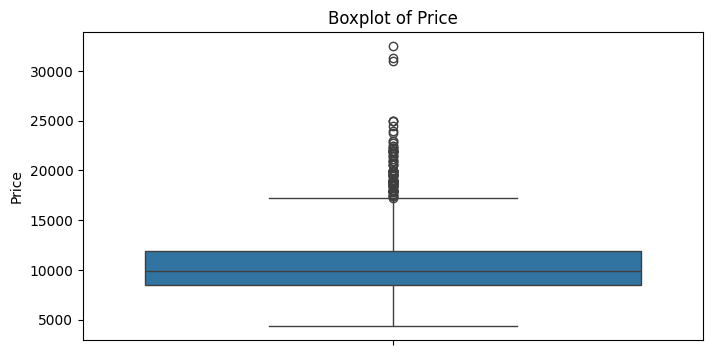

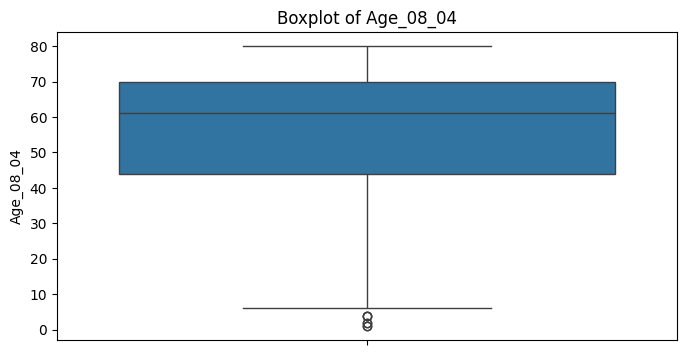

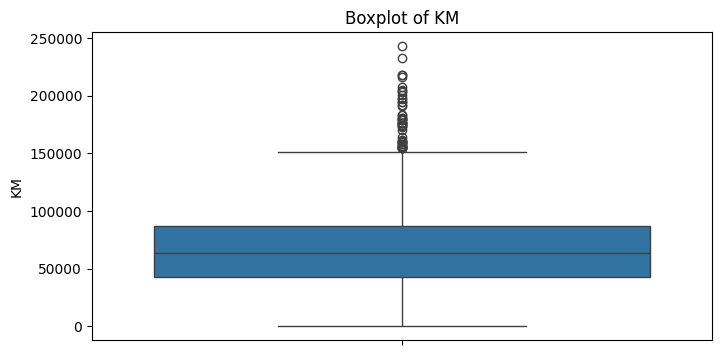

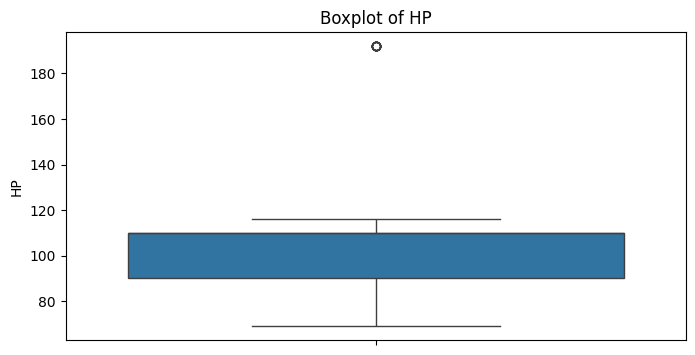

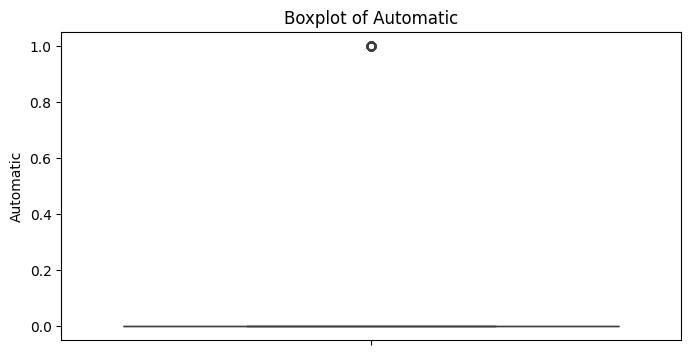

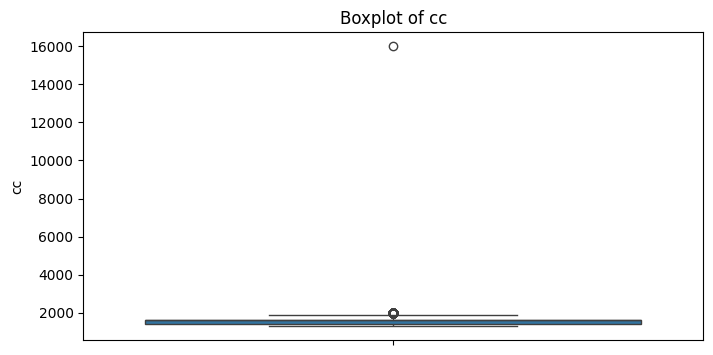

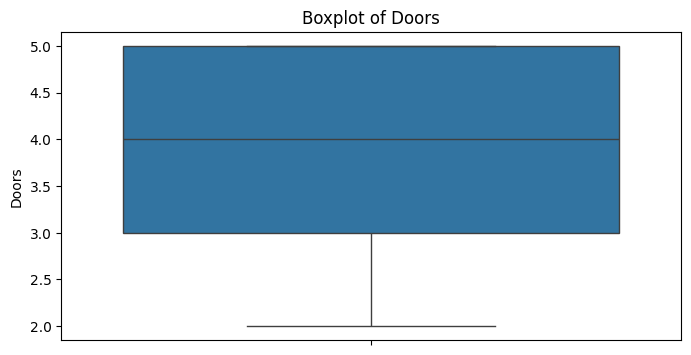

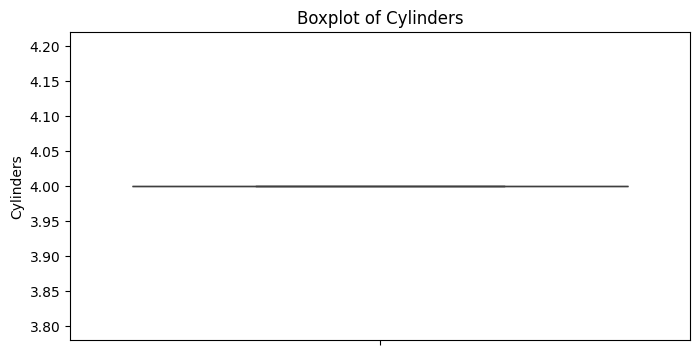

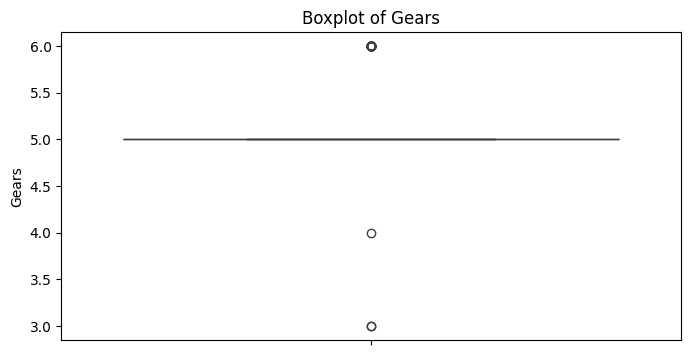

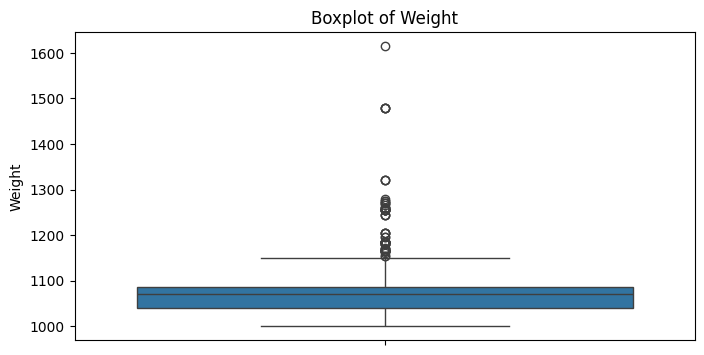

In [ ]:
numerical_columns = car.select_dtypes(include=np.number).columns
for i in numerical_columns:
  plt.figure(figsize=(8,4))
  sns.boxplot(car[i])
  plt.title(f"Boxplot of {i}")
  plt.show()
  print(' ')

**Outlier Treatment**

Outliers in column 'Price' treated using IQR method.
Outliers in column 'Age_08_04' treated using IQR method.
Outliers in column 'KM' treated using IQR method.
Outliers in column 'HP' treated using IQR method.
Outliers in column 'Automatic' treated using IQR method.
Outliers in column 'cc' treated using IQR method.
Outliers in column 'Gears' treated using IQR method.
Outliers in column 'Weight' treated using IQR method.
Outlier treatment complete. Displaying boxplots after treatment:


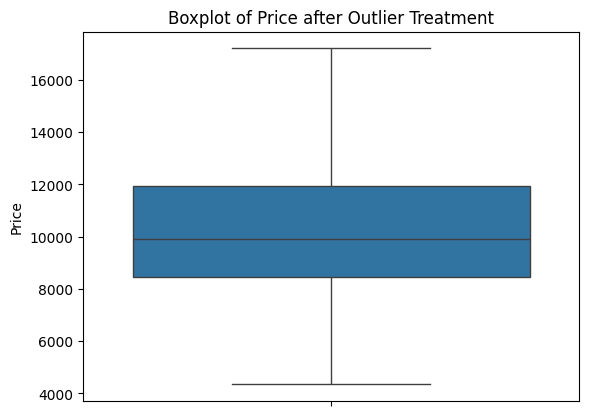

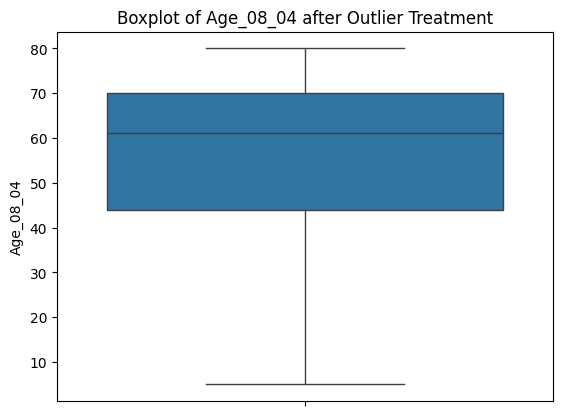

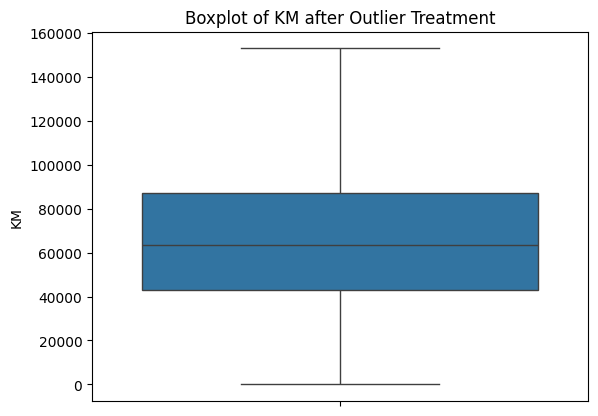

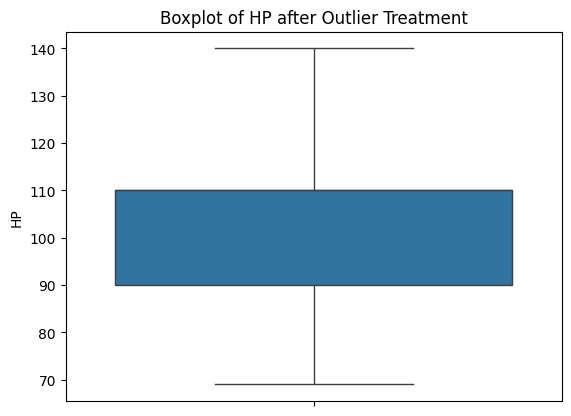

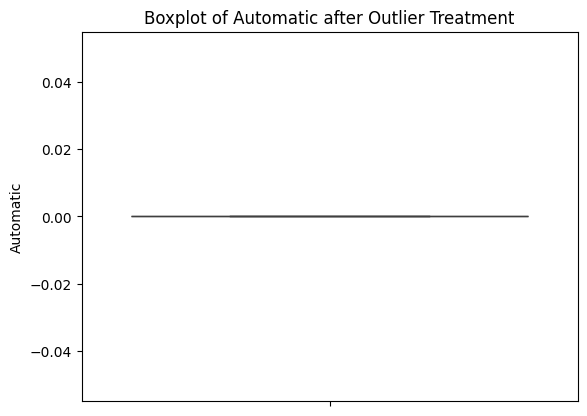

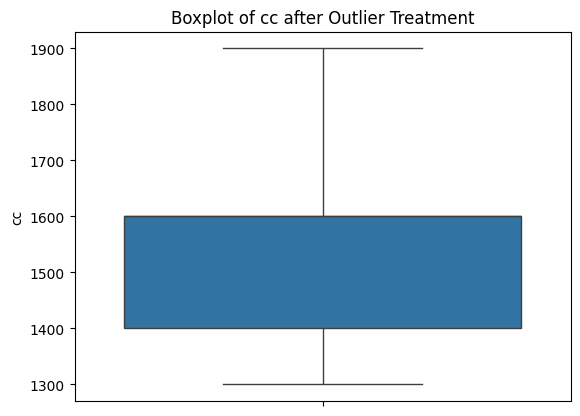

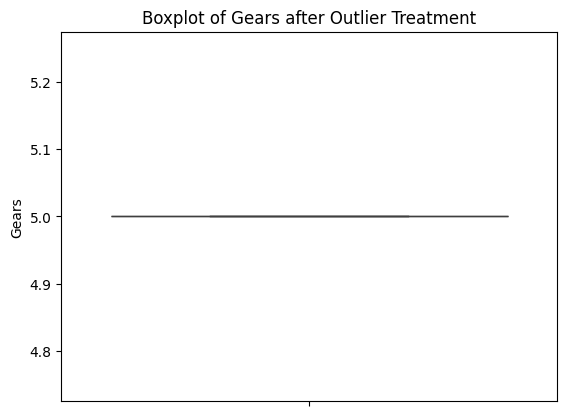

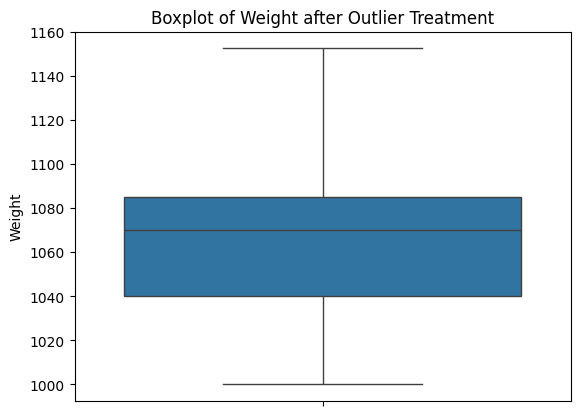

In [ ]:
outlier_clmns=['Price','Age_08_04','KM','HP','Automatic','cc','Gears','Weight']
for col in outlier_clmns:
  Q1=car[col].quantile(0.25)
  Q3=car[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound =Q3+1.5*IQR

  car[col]=car[col].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))
  print(f"Outliers in column '{col}' treated using IQR method.")
print("Outlier treatment complete. Displaying boxplots after treatment:")

for col in outlier_clmns:
  sns.boxplot(car[col])
  plt.title(f'Boxplot of {col} after Outlier Treatment')
  plt.show()
  print(' ')

In [ ]:
numerical_columns = car.select_dtypes(include=np.number).columns
for col_name in numerical_columns:
  print(f"--------------{col_name}-------------------")
  print(f"Mean of {col_name}               : {car[col_name].mean()}")
  print(f"Median of {col_name}             :{car[col_name].median()}")
  print(f"Standard deviation of {col_name} :{car[col_name].std()})")
  Q1=car[col_name].quantile(0.25)
  Q3=car[col_name].quantile(0.75)
  IQR=Q3-Q1
  print(f"IQR of {col_name}                :{IQR}")

--------------Price-------------------
Mean of Price               : 10500.633008356546
Median of Price             :9900.0
Standard deviation of Price :2981.8136717838797)
IQR of Price                :3500.0
--------------Age_08_04-------------------
Mean of Age_08_04               : 55.95891364902507
Median of Age_08_04             :61.0
Standard deviation of Age_08_04 :18.56651243249861)
IQR of Age_08_04                :26.0
--------------KM-------------------
Mean of KM               : 67604.87317200557
Median of KM             :63389.5
Standard deviation of KM :34738.59545418552)
IQR of KM                :44020.75
--------------HP-------------------
Mean of HP               : 101.10376044568245
Median of HP             :110.0
Standard deviation of HP :13.147449500108497)
IQR of HP                :20.0
--------------Automatic-------------------
Mean of Automatic               : 0.0
Median of Automatic             :0.0
Standard deviation of Automatic :0.0)
IQR of Automatic          

In [ ]:
car.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.00000,1436.0,1436.000000,1436.000000,1436.0,1436.0,1436.000000
mean,10500.633008,55.958914,67604.873172,101.10376,0.0,1558.565460,4.033426,4.0,5.0,1068.579387
std,2981.813672,18.566512,34738.595454,13.14745,0.0,168.970222,0.952677,0.0,0.0,37.774625
min,4350.000000,5.000000,1.000000,69.00000,0.0,1300.000000,2.000000,4.0,5.0,1000.000000
25%,8450.000000,44.000000,43000.000000,90.00000,0.0,1400.000000,3.000000,4.0,5.0,1040.000000
50%,9900.000000,61.000000,63389.500000,110.00000,0.0,1600.000000,4.000000,4.0,5.0,1070.000000
75%,11950.000000,70.000000,87020.750000,110.00000,0.0,1600.000000,5.000000,4.0,5.0,1085.000000
max,17200.000000,80.000000,153051.875000,140.00000,0.0,1900.000000,5.000000,4.0,5.0,1152.500000


**Data Visualizations**

**Histograms**

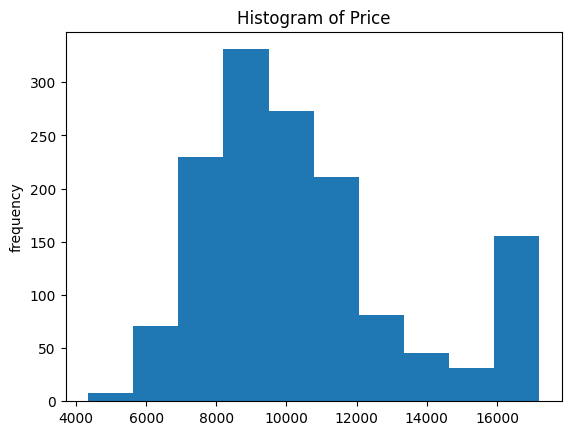

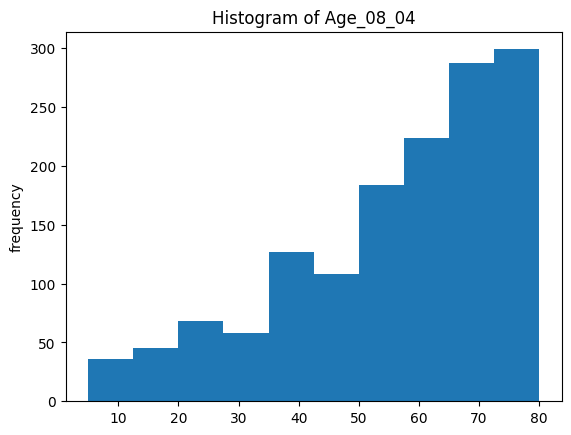

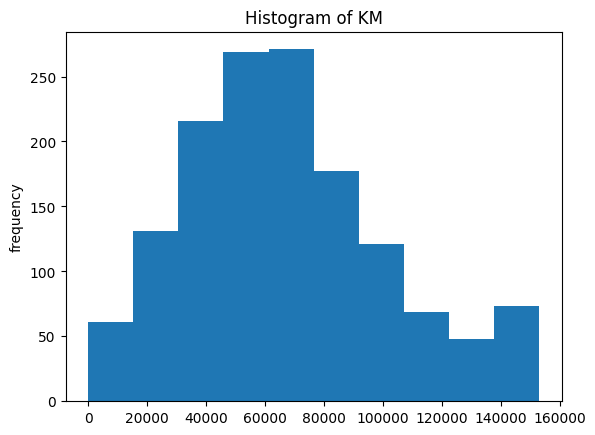

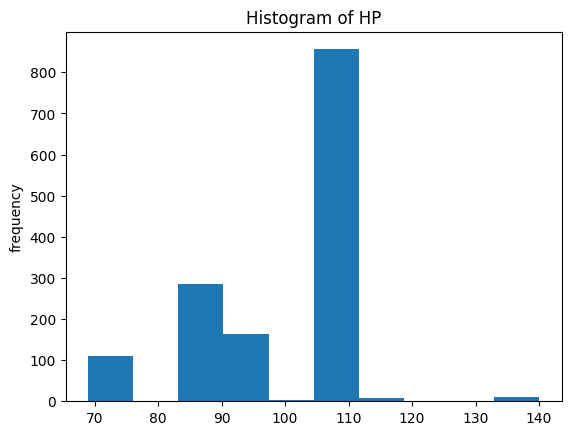

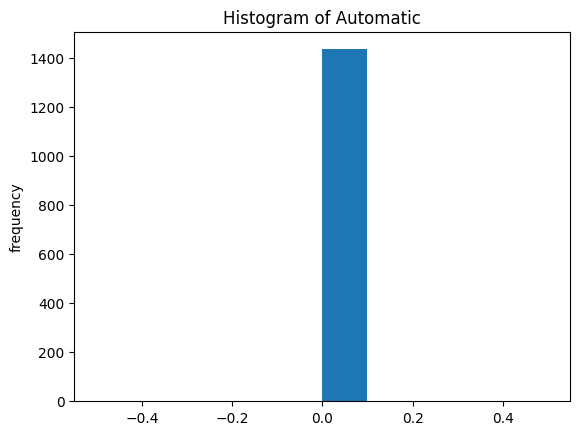

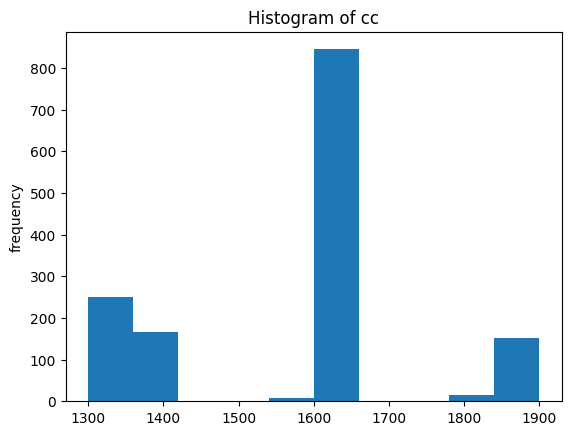

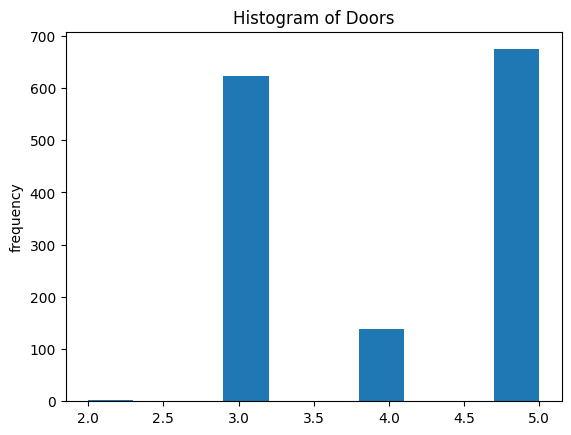

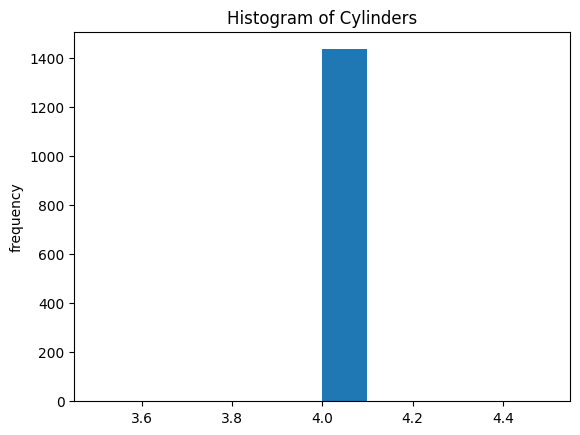

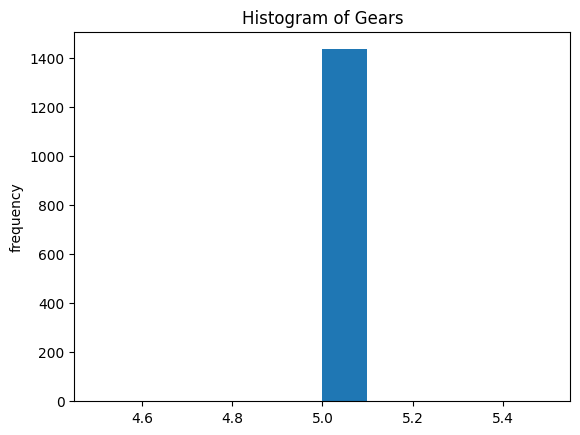

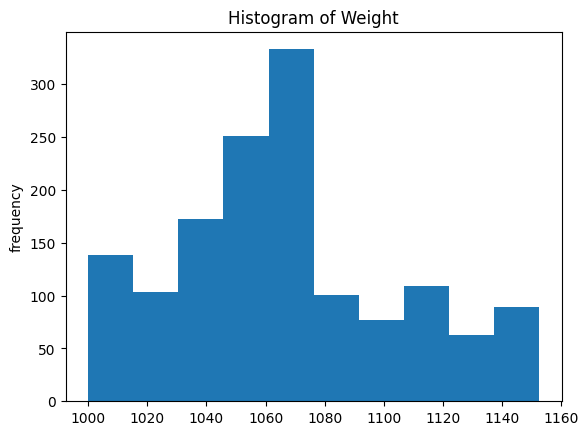

In [ ]:
for col in numerical_columns:
  plt.hist(car[col])
  plt.title(f"Histogram of {col}")
  plt.ylabel('frequency')
  plt.show()
  print(' ')

**Bar Chart**

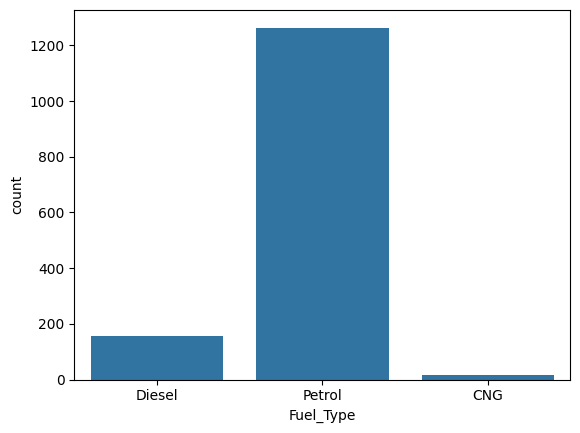

In [ ]:
sns.countplot(x='Fuel_Type',data=car)
plt.show()

**Piechart**

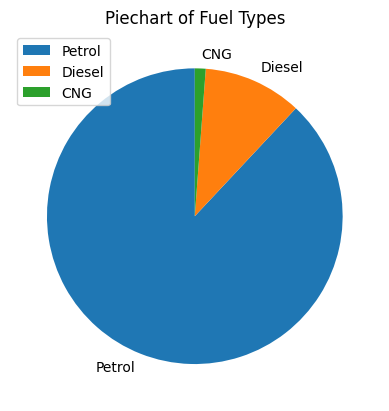

In [ ]:
fuel_type_counts=car['Fuel_Type'].value_counts()
#print(fuel_type_counts)
plt.pie(fuel_type_counts,labels=fuel_type_counts.index,startangle=90)
plt.title('Piechart of Fuel Types')
plt.legend()
plt.show()

**Scatter plots**

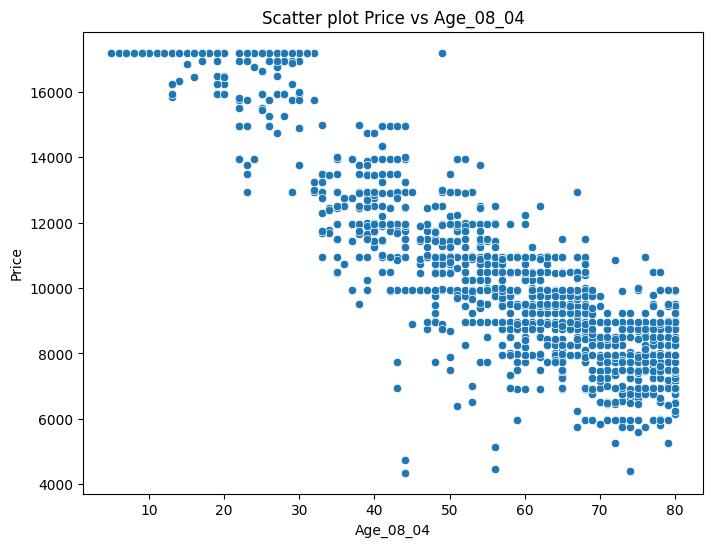

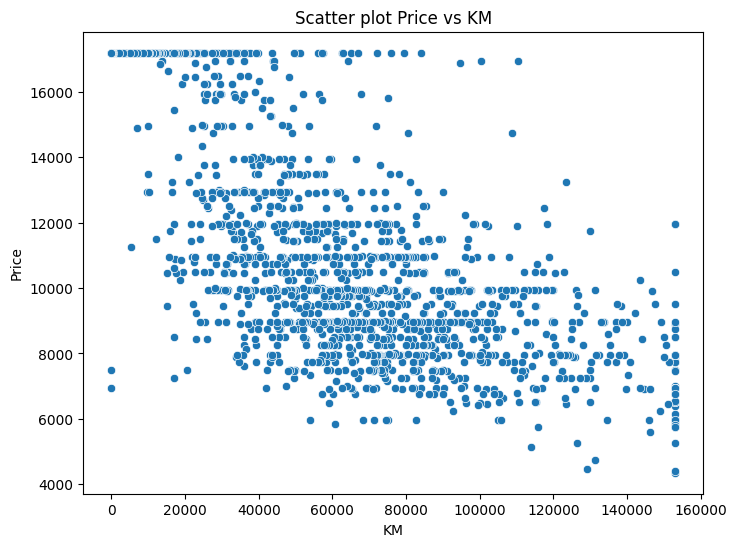

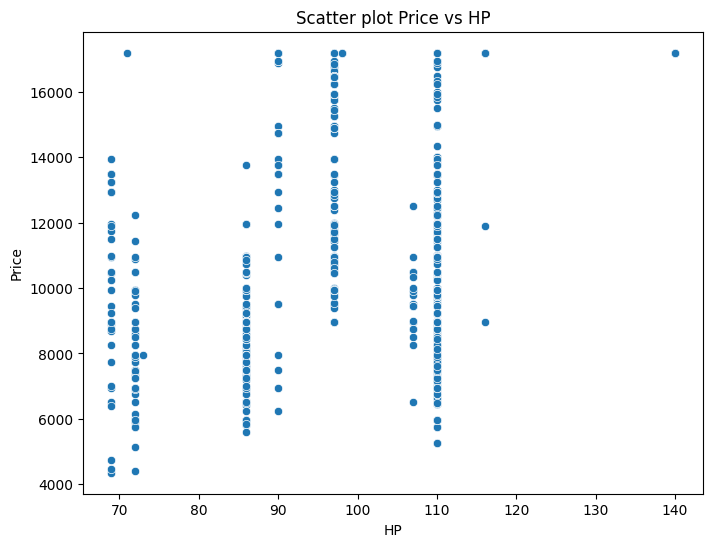

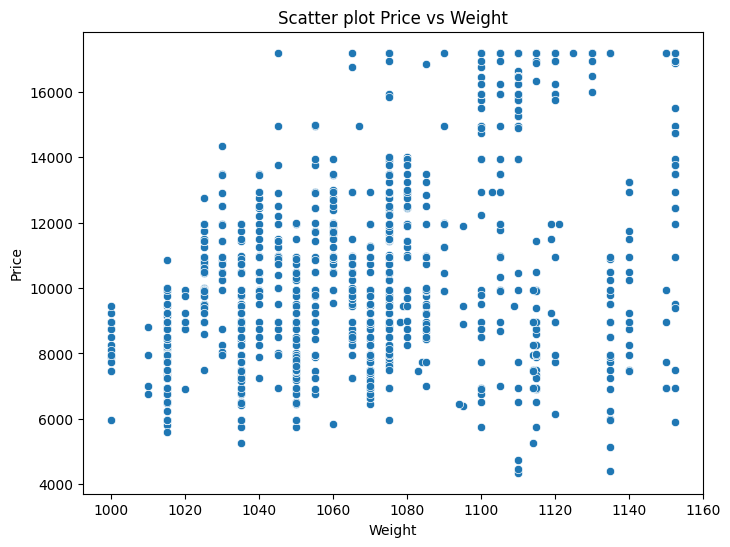

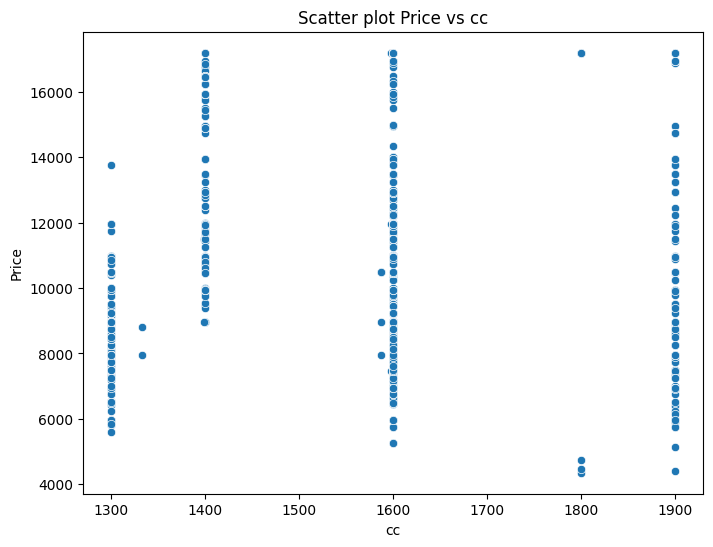

In [ ]:
#Price vs Age
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age_08_04',y='Price',data=car)
plt.title('Scatter plot Price vs Age_08_04')
plt.show()
print(' ')

# Price vs. KM
plt.figure(figsize=(8, 6))
sns.scatterplot(x='KM', y='Price', data=car)
plt.title('Scatter plot Price vs KM')
plt.show()
print(' ')

# Price vs. HP
plt.figure(figsize=(8, 6))
sns.scatterplot(x='HP', y='Price', data=car)
plt.title('Scatter plot Price vs HP')
plt.show()
print(' ')

# Price vs. Weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Weight', y='Price', data=car)
plt.title('Scatter plot Price vs Weight')
plt.show()
print(' ')

# Price vs. cc
plt.figure(figsize=(8, 6))
sns.scatterplot(x='cc', y='Price', data=car)
plt.title('Scatter plot Price vs cc')
plt.show()
print(' ')

**correlation heatmaps**

In [ ]:
car_encoded = pd.get_dummies(car, columns=['Fuel_Type'], drop_first=True)
correlation_matrix=car_encoded.corr()
print(car_encoded.head())
print(correlation_matrix.head())


     Price  Age_08_04       KM    HP  Automatic      cc  Doors  Cylinders  \
0  13500.0       23.0  46986.0  90.0        0.0  1900.0      3          4   
1  13750.0       23.0  72937.0  90.0        0.0  1900.0      3          4   
2  13950.0       24.0  41711.0  90.0        0.0  1900.0      3          4   
3  14950.0       26.0  48000.0  90.0        0.0  1900.0      3          4   
4  13750.0       30.0  38500.0  90.0        0.0  1900.0      3          4   

   Gears  Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0    5.0  1152.5              True             False  
1    5.0  1152.5              True             False  
2    5.0  1152.5              True             False  
3    5.0  1152.5              True             False  
4    5.0  1152.5              True             False  
              Price  Age_08_04        KM        HP  Automatic        cc  \
Price      1.000000  -0.895728 -0.608832  0.255640        NaN  0.132106   
Age_08_04 -0.895728   1.000000  0.531839 -0.131284       

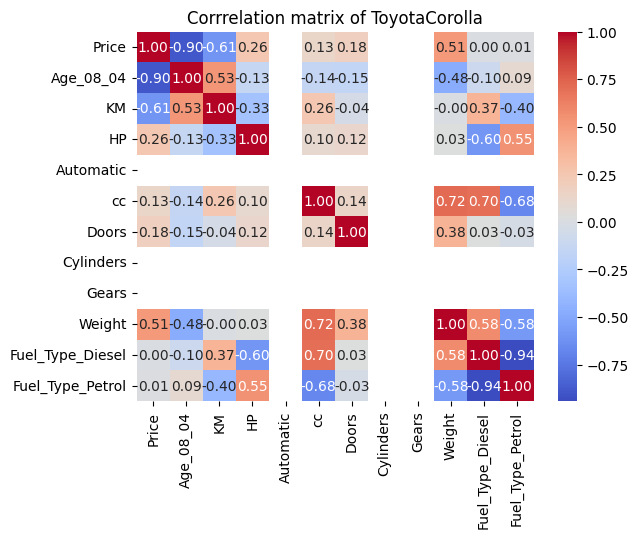

In [ ]:
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Corrrelation matrix of ToyotaCorolla')
plt.show()

**Pariplot**

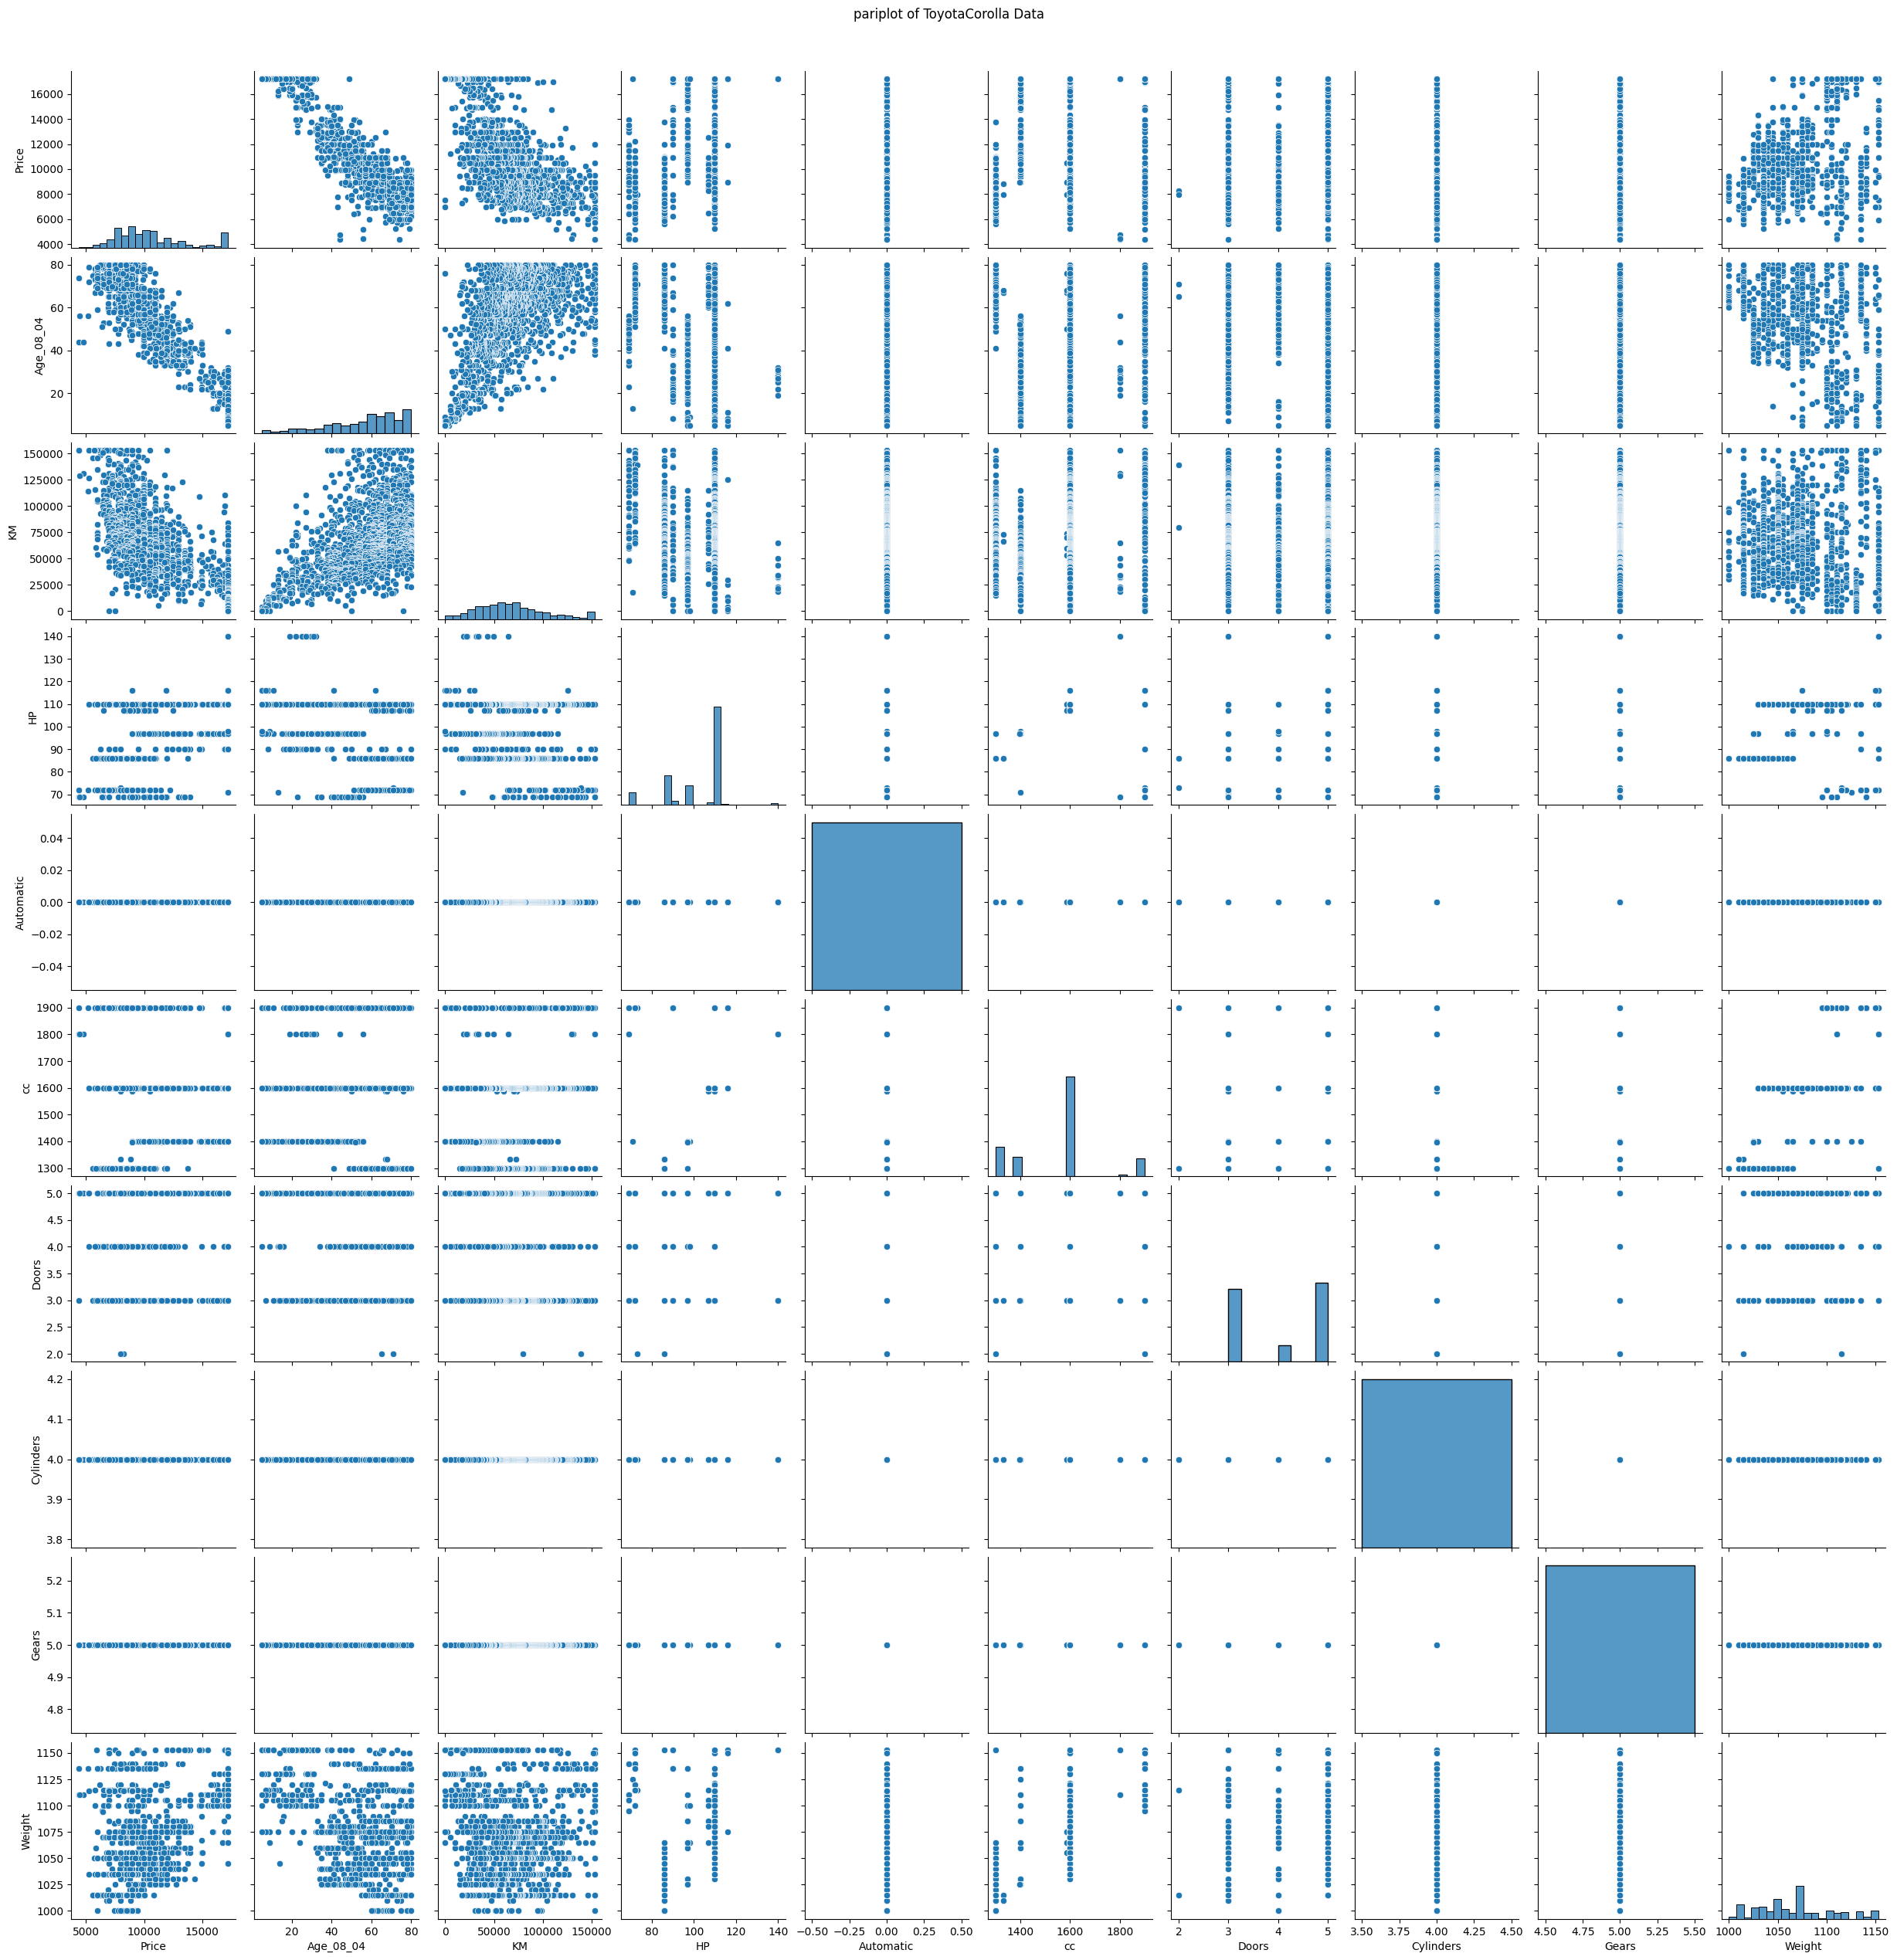

In [ ]:
sns.pairplot(car)
plt.suptitle('pariplot of ToyotaCorolla Data',y=1.02)
plt.show()

**Violin plot**

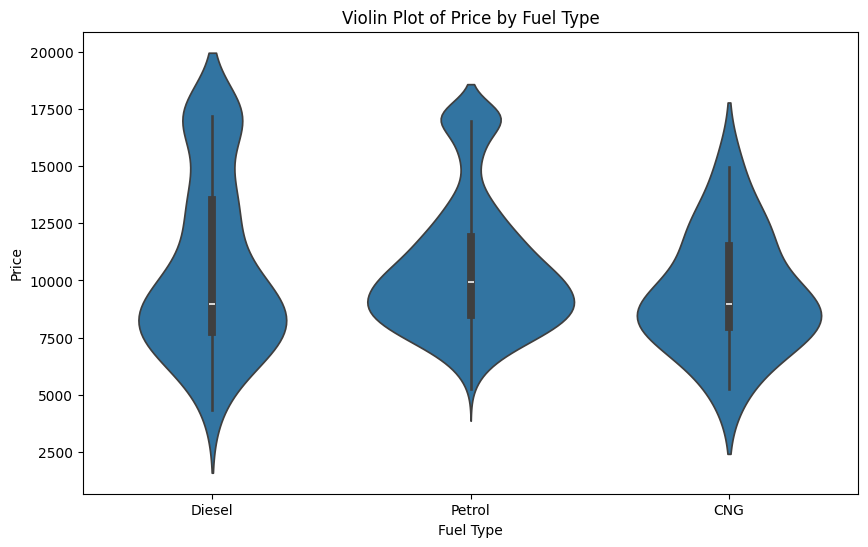

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Fuel_Type', y='Price', data=car)
plt.title('Violin Plot of Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

In [ ]:
car.isna().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
car

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1025.0
1432,10845.0,72.0,19000.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0
1433,8500.0,71.0,17016.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0
1434,7250.0,70.0,16916.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0


In [ ]:
car['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [ ]:
pd.get_dummies(car['Fuel_Type']).astype(int)

,CNG,Diesel,Petrol
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
1431,0,0,1
1432,0,0,1
1433,0,0,1
1434,0,0,1


In [ ]:
categorical_features=['Fuel_Type']

In [ ]:
car_encoded_df=pd.get_dummies(car[columns],columns=categorical_features,drop_first=True)

In [ ]:
car_encoded_df.columns

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'],
      dtype='object')

In [ ]:
X_features=car_encoded_df.drop('Price',axis=1)

In [ ]:
X_features.columns

Index(['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders',
       'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'],
      dtype='object')

**Normalization/Standardization**

In [ ]:
from scipy.stats import zscore

In [ ]:
car['Z_score_price']=zscore(car.Price)

In [ ]:
car[(car.Z_score_price>3.0) | (car.Z_score_price< -3.0)]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Z_score_price


 So, there are no observations that are outliers as per the Z-score.

# **2.Splitting the Dataset into Train and Validation Sets(80% training, 20% testing)**

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as smf

In [ ]:
X=smf.add_constant(car_encoded_df.drop('Price',axis=1).astype(int))

In [ ]:
X

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,90,0,1900,3,4,5,1152,1,0
1,23,72937,90,0,1900,3,4,5,1152,1,0
2,24,41711,90,0,1900,3,4,5,1152,1,0
3,26,48000,90,0,1900,3,4,5,1152,1,0
4,30,38500,90,0,1900,3,4,5,1152,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1431,69,20544,86,0,1300,3,4,5,1025,0,1
1432,72,19000,86,0,1300,3,4,5,1015,0,1
1433,71,17016,86,0,1300,3,4,5,1015,0,1
1434,70,16916,86,0,1300,3,4,5,1015,0,1


In [ ]:
Y=car_encoded_df['Price']

In [ ]:
Y

,Price
0,13500.0
1,13750.0
2,13950.0
3,14950.0
4,13750.0
...,...
1431,7500.0
1432,10845.0
1433,8500.0
1434,7250.0


In [ ]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_Y,test_Y=train_test_split(X,Y,train_size=0.8,random_state=42)

In [ ]:
train_X

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
899,62,59295,86,0,1300,5,4,5,1035,0,1
881,68,61568,110,0,1600,4,4,5,1035,0,1
310,40,38653,110,0,1600,5,4,5,1080,0,1
1145,75,101855,110,0,1600,5,4,5,1070,0,1
31,22,35199,97,0,1400,3,4,5,1100,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1095,76,125778,110,0,1600,3,4,5,1050,0,1
1130,73,107108,110,0,1600,3,4,5,1050,0,1
1294,80,71740,110,0,1600,5,4,5,1070,0,1
860,63,64690,86,0,1300,3,4,5,1020,0,1


In [ ]:
test_X

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
594,50,22500,97,0,1400,3,4,5,1025,0,1
754,68,80426,110,0,1600,3,4,5,1055,0,1
630,59,130000,72,0,1900,4,4,5,1135,1,0
1259,71,76000,110,0,1600,5,4,5,1070,0,1
903,65,59000,110,0,1600,5,4,5,1075,0,1
...,...,...,...,...,...,...,...,...,...,...,...
174,8,9788,110,0,1600,5,4,5,1130,0,1
1428,72,26000,86,0,1300,3,4,5,1015,0,1
297,40,41339,110,0,1600,5,4,5,1080,0,1
1435,76,1,110,0,1600,5,4,5,1114,0,1


In [ ]:
train_Y

,Price
899,9500.0
881,9795.0
310,12950.0
1145,6450.0
31,15750.0
...,...
1095,6900.0
1130,7950.0
1294,6950.0
860,9750.0


In [ ]:
test_Y

,Price
594,10800.0
754,9950.0
630,7500.0
1259,9250.0
903,9750.0
...,...
174,17200.0
1428,8450.0
297,12850.0
1435,6950.0


# **3.Building a multiple linear regression model using the training dataset. Interpreting the coefficients of the model. Building 3 different models.**

In [ ]:
car_1=smf.OLS(train_Y,train_X).fit()

In [ ]:
car_1.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Results: Ordinary least squares
=========================================================================
Model:                OLS                Adj. R-squared:       0.866     
Dependent Variable:   Price              AIC:                  19337.7257
Date:                 2025-11-22 10:06   BIC:                  19383.1377
No. Observations:     1148               Log-Likelihood:       -9659.9   
Df Model:             8                  F-statistic:          927.3     
Df Residuals:         1139               Prob (F-statistic):   0.00      
R-squared:            0.867              Scale:                1.2014e+06
-------------------------------------------------------------------------
                   Coef.    Std.Err.    t     P>|t|    [0.025     0.975] 
-------------------------------------------------------------------------
Age_08_04         -106.4266   2.5636 -41.5140 0.0000  -111.4566 -101.3967
KM                  -0.0143   0.0013 -10.6964 0.0000    -0.0170   -0.0117
HP                  27.6637   7.5216   3.6779 0.0002    12.9059   42.4215
Automatic           -0.0000   0.0000  -5.4807 0.0000    -0.0000   -0.0000
cc                  -2.5257   0.6670  -3.7865 0.0002    -3.8344   -1.2169
Doors              -97.9550  38.4404  -2.5482 0.0110  -173.3768  -22.5331
Cylinders         -878.5735 160.0618  -5.4890 0.0000 -1192.6225 -564.5244
Gears            -1098.2168 200.0772  -5.4890 0.0000 -1490.7781 -705.6555
Weight              25.0010   1.6840  14.8462 0.0000    21.6969   28.3052
Fuel_Type_Diesel  1190.2039 506.6575   2.3491 0.0190   196.1171 2184.2908
Fuel_Type_Petrol  1283.7309 281.2251   4.5648 0.0000   731.9536 1835.5082
-------------------------------------------------------------------------
Omnibus:            58.827     Durbin-Watson:        2.019               
Prob(Omnibus):      0.000      Jarque-Bera (JB):     179.408             
Skew:               -0.164     Prob(JB):             0.000               
Kurtosis:           4.909      Condition No.:        77456249993930162176
=========================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
[2] The smallest eigenvalue is 1.11e-27. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

**Multi-Collinearity and Handling Multi-Collinearity**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
def get_vif_factors(X):
  X_matrix=X.values
  #print('---------------X_matrix-----------')
  #print(X_matrix)
  #print('--------------X_matrix shape----------------')
  #print(X_matrix.shape)
  vif=[variance_inflation_factor(X_matrix,i)  for i in range(X_matrix.shape[1])]
  #print('i : ',i)
  #print('------------X_MATRIX----------')
  #print(X_matrix)
  vif_factors=pd.DataFrame()
  #print('vif_factors',vif_factors)
  vif_factors['column']=X.columns
  #print('vif_factors',vif_factors)
  vif_factors['VIF']=vif
  #print('vif_factors',vif_factors)
  return vif_factors

In [ ]:
import warnings
warnings.filterwarnings('ignore')
vif_factors=get_vif_factors(X)

In [ ]:
vif_factors

,column,VIF
0,Age_08_04,2.191757
1,KM,2.018060
2,HP,9.683922
3,Automatic,NaN
4,cc,12.467879
5,Doors,1.303071
6,Cylinders,0.000000
7,Gears,0.000000
8,Weight,3.859358
9,Fuel_Type_Diesel,26.066031


In [ ]:
vif_factors[vif_factors.VIF>4]

,column,VIF
2,HP,9.683922
4,cc,12.467879
9,Fuel_Type_Diesel,26.066031
10,Fuel_Type_Petrol,9.741778


In [ ]:
columns_with_large_vif=vif_factors[vif_factors.VIF>4]['column']

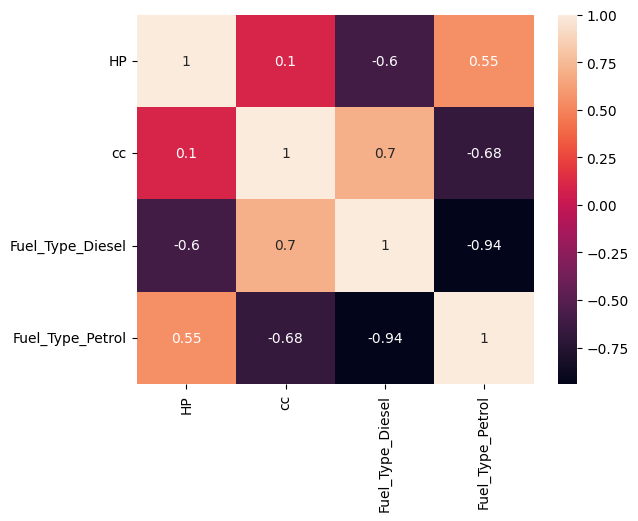

In [ ]:
sns.heatmap(X[columns_with_large_vif].corr(),annot=True)
plt.show()

In [ ]:
columns_to_be_removed=['Fuel_Type_Petrol','HP','cc','Fuel_Type_Diesel']

In [ ]:
X_New_features=list(set(X_features)-set(columns_to_be_removed))
X_New_features

['KM', 'Weight', 'Cylinders', 'Doors', 'Automatic', 'Gears', 'Age_08_04']

In [ ]:
get_vif_factors(X[X_New_features])

,column,VIF
0,KM,1.587700
1,Weight,1.689504
2,Cylinders,0.000000
3,Doors,1.181587
4,Automatic,NaN
5,Gears,0.000000
6,Age_08_04,2.058074


**Building a New Model after Removing Multi-collinearity**

In [ ]:
train_X=train_X[X_New_features]
#train_X
car_2=smf.OLS(train_Y,train_X).fit()
car_2.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.850     
Dependent Variable: Price            AIC:                19459.3539
Date:               2025-11-22 10:06 BIC:                19484.5828
No. Observations:   1148             Log-Likelihood:     -9724.7   
Df Model:           4                F-statistic:        1632.     
Df Residuals:       1143             Prob (F-statistic): 0.00      
R-squared:          0.851            Scale:              1.3403e+06
-------------------------------------------------------------------
               Coef.   Std.Err.    t     P>|t|    [0.025    0.975] 
-------------------------------------------------------------------
KM             -0.0216   0.0013 -17.2397 0.0000   -0.0240   -0.0191
Weight         14.7932   1.1569  12.7867 0.0000   12.5233   17.0632
Cylinders     203.3799 121.9639   1.6675 0.0957  -35.9184  442.6781
Doors          22.3943  38.5279   0.5812 0.5612  -53.1990   97.9875
Automatic      -0.0000   0.0000  -1.3261 0.1851   -0.0000    0.0000
Gears         254.2249 152.4549   1.6675 0.0957  -44.8979  553.3477
Age_08_04    -107.5612   2.6241 -40.9903 0.0000 -112.7097 -102.4127
-------------------------------------------------------------------
Omnibus:        103.785  Durbin-Watson:     2.020                  
Prob(Omnibus):  0.000    Jarque-Bera (JB):  299.361                
Skew:           -0.459   Prob(JB):          0.000                  
Kurtosis:       5.328    Condition No.:     27030659682580486422528
===================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors
is correctly specified.
[2] The smallest eigenvalue is 9.13e-33. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

In [ ]:
# 'Weight','Age_08_04','KM' has p-value<0.05

In [ ]:
significant_vars=['Weight','Age_08_04','KM']
train_X=train_X[significant_vars]
car_3=smf.OLS(train_Y,train_X).fit()
car_3.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.989     
Dependent Variable:     Price            AIC:                         19458.1952
Date:                   2025-11-22 10:06 BIC:                         19473.3325
No. Observations:       1148             Log-Likelihood:              -9726.1   
Df Model:               3                F-statistic:                 3.378e+04 
Df Residuals:           1145             Prob (F-statistic):          0.00      
R-squared (uncentered): 0.989            Scale:                       1.3413e+06
-----------------------------------------------------------------------------------
                Coef.      Std.Err.       t        P>|t|       [0.025       0.975] 
-----------------------------------------------------------------------------------
Weight          16.7335      0.0967    173.0895    0.0000      16.5438      16.9232
Age_08_04     -104.8908      2.0592    -50.9385    0.0000    -108.9309    -100.8506
KM              -0.0223      0.0012    -19.0583    0.0000      -0.0246      -0.0200
--------------------------------------------------------------------------------
Omnibus:                   114.008           Durbin-Watson:              2.015  
Prob(Omnibus):             0.000             Jarque-Bera (JB):           331.435
Skew:                      -0.505            Prob(JB):                   0.000  
Kurtosis:                  5.431             Condition No.:              4596   
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[3] The condition number is large, 4.6e+03. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

**Interpreting the coefficients of the car_3 model**

Here's the interpretation of the coefficients for the car_3 model:

**Weight (16.7335)**: For every one-unit increase in the car's weight, the predicted price increases by approximately 16.73 units, assuming all other factors remain constant. This suggests that heavier cars tend to be more expensive.

**Age_08_04 (-104.8908)**: For every one-unit increase in the car's age (in months), the predicted price decreases by approximately 104.89 units, holding all other variables constant. This is an expected inverse relationship, as older cars typically have lower prices.

**KM (-0.0223)**: For every one-unit increase in kilometers driven, the predicted price decreases by approximately 0.0223 units, assuming all other factors are held constant. This also indicates an expected inverse relationship, as higher mileage generally leads to lower car prices.

The model's uncentered R-squared value is 0.989, which means that approximately 98.9% of the variance in car prices can be explained by the Weight, Age_08_04, and KM features in this model.

**Residual Analysis**

**Check for Normal Distribution of Residual**

In [ ]:
car_3_resid=car_3.resid
car_3_resid

,0
899,6.382432
881,981.415759
310,-64.544641
1145,-1316.606259
31,435.726590
...,...
1095,106.445207
1130,425.425387
1294,-963.727386
860,732.585679


<Figure size 800x600 with 0 Axes>

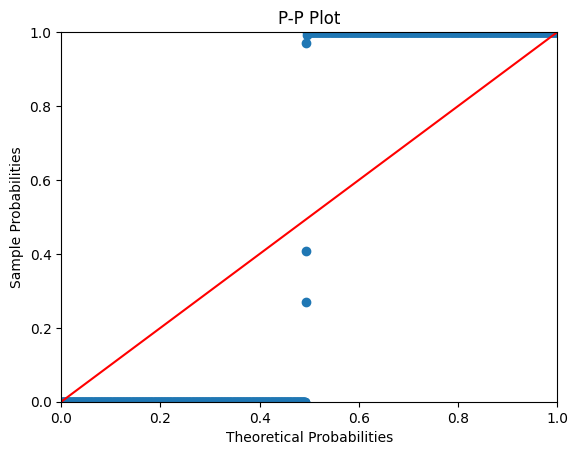

In [ ]:
probplot=smf.ProbPlot(car_3_resid)
plt.figure(figsize=(8,6))
probplot.ppplot(line='45')
plt.title('P-P Plot')
plt.show()

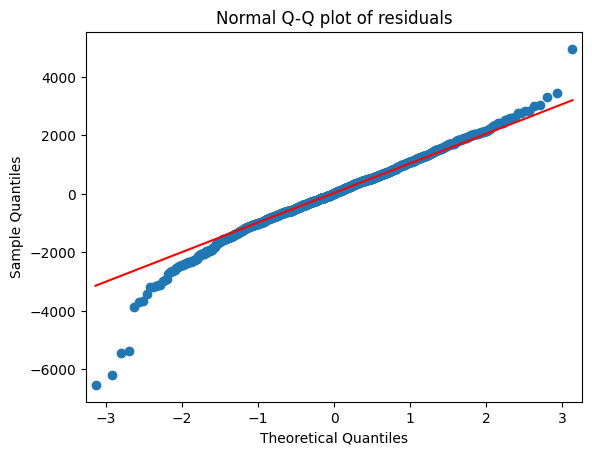

In [ ]:
qqplot=smf.qqplot(car_3.resid,line='q') # line = 45 to draw the diagnoal line
plt.title("Normal Q-Q plot of residuals")
plt.show()

**Test of Homoscedasticity**

In [ ]:
def get_standardized_values(vals):
  return (vals-vals.mean())/vals.std()

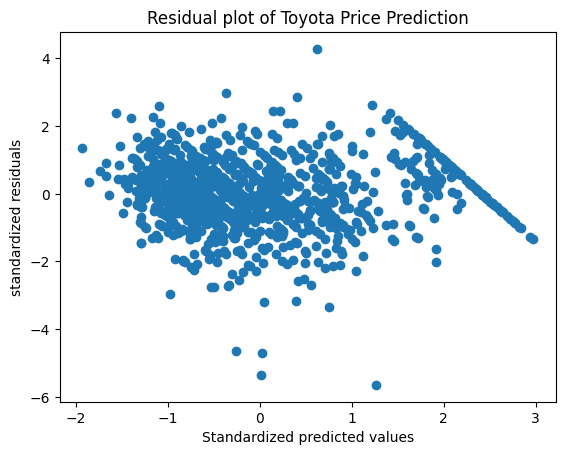

In [ ]:
plt.scatter(get_standardized_values(car_3.fittedvalues),get_standardized_values(car_3_resid))
plt.title('Residual plot of Toyota Price Prediction')
plt.xlabel('Standardized predicted values')
plt.ylabel('standardized residuals')
plt.show()

# **4.Evaluating the performance of the model using appropriate evaluation metrics on the testing dataset.**

In [ ]:
pred_Y=car_3.predict(test_X[train_X.columns])
pred_Y

,0
594,11405.513423
754,8727.713734
630,9904.891065
1259,8762.744854
903,9854.862776
...,...
174,17851.422567
1428,8852.530479
297,12954.645905
1435,10669.367977


**Meansuring Mean Squared Error(MSE)**

In [ ]:
from sklearn import metrics
print('Mean Squaerd Error: ',metrics.mean_squared_error(pred_Y,test_Y))

Mean Squaerd Error:  1298552.3025757894


**Measuring RMSE**

In [ ]:
from sklearn import metrics
print('Root Mean Squared Error: ',np.sqrt(metrics.mean_squared_error(pred_Y,test_Y)))

Root Mean Squared Error:  1139.5403909365343


**Measuring R-squared Value**

In [ ]:
print('R-Squared Value: ',metrics.r2_score(pred_Y,test_Y))

R-Squared Value:  0.8203665804412814


**Measuring Mean Absolute Error(MAE)**

In [ ]:
print('Mean Absolute Error: ',metrics.mean_absolute_error(pred_Y,test_Y))

Mean Absolute Error:  859.4439032413209


**Standardization of X and Y**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X_scaler=StandardScaler()
X_scaled=X_scaler.fit_transform(X)
Y=(Y-Y.mean())/Y.std()


In [ ]:
X_scaled

array([[-1.77579907, -0.59375083, -0.84485045, ...,  2.21274112,
         2.87480715, -2.71087388],
       [-1.77579907,  0.15354753, -0.84485045, ...,  2.21274112,
         2.87480715, -2.71087388],
       [-1.7219199 , -0.74565245, -0.84485045, ...,  2.21274112,
         2.87480715, -2.71087388],
       ...,
       [ 0.81040132, -1.45678239, -1.14919796, ..., -1.42019846,
        -0.34784942,  0.36888474],
       [ 0.75652215, -1.45966204, -1.14919796, ..., -1.42019846,
        -0.34784942,  0.36888474],
       [ 1.0797972 , -1.94675509,  0.67688708, ...,  1.20506444,
        -0.34784942,  0.36888474]])

In [ ]:
Y

,Price
0,1.005887
1,1.089728
2,1.156802
3,1.492168
4,1.089728
...,...
1431,-1.006311
1432,0.115489
1433,-0.670945
1434,-1.090153


Splitting the Dataset into Train and Test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X,test_X,train_Y,test_Y=train_test_split(X_scaled,Y,test_size=0.2,random_state=42)

**Building the Model**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linreg=LinearRegression()
linreg

LinearRegression()

In [ ]:
linreg.fit(train_X,train_Y)

LinearRegression()

In [ ]:
LinearRegression(copy_X=True,fit_intercept=True,n_jobs=1)

LinearRegression(n_jobs=1)

In [ ]:
linreg.coef_

array([-6.62443661e-01, -1.66879195e-01,  1.21932653e-01,  2.42861287e-17,
       -1.43072790e-01, -3.12852924e-02,  8.67361738e-18,  0.00000000e+00,
        3.16184170e-01,  1.23858796e-01,  1.39790229e-01])

**Interpreting the coefficients of the linreg model**

Interpreting Standardized Coefficients: Since the features and the target variable (Price) were standardized (transformed to have a mean of 0 and a standard deviation of 1) before fitting the linreg model, the coefficients represent the change in the standardized Price for a one standard deviation increase in the corresponding feature, holding all other features constant.

Age_08_04 (-0.6624): For every one standard deviation increase in 'Age_08_04' (meaning the car is older), the standardized 'Price' is expected to decrease by approximately 0.6624 standard deviations, assuming all other features are held constant. This indicates a strong negative relationship.

KM (-0.1669): For every one standard deviation increase in 'KM' (meaning higher mileage), the standardized 'Price' is expected to decrease by approximately 0.1669 standard deviations, holding all other features constant. This also shows a negative relationship.

HP (0.1219): For every one standard deviation increase in 'HP' (meaning higher horsepower), the standardized 'Price' is expected to increase by approximately 0.1219 standard deviations, holding all other features constant. This suggests a positive relationship.

Automatic (2.4286e-17): The coefficient is extremely close to zero, suggesting that 'Automatic' (likely a binary indicator) has virtually no linear impact on the standardized 'Price' when other factors are controlled.

cc (-0.1431): For every one standard deviation increase in 'cc' (engine displacement), the standardized 'Price' is expected to decrease by approximately 0.1431 standard deviations, holding all other features constant. This is a somewhat counter-intuitive negative relationship, but it's important to remember this is within the context of other variables.

Doors (-0.0313): For every one standard deviation increase in 'Doors', the standardized 'Price' is expected to decrease by approximately 0.0313 standard deviations, holding all other features constant. A very small negative impact.

Cylinders (8.6736e-18): Similar to 'Automatic', this coefficient is extremely close to zero, indicating no practical linear impact on the standardized 'Price'.

Gears (0.0000): This coefficient is exactly zero, implying no linear relationship with the standardized 'Price' in this model.

Weight (0.3162): For every one standard deviation increase in 'Weight', the standardized 'Price' is expected to increase by approximately 0.3162 standard deviations, holding all other features constant. This shows a positive relationship.

Fuel_Type_Diesel (0.1239): For a one standard deviation increase in 'Fuel_Type_Diesel' (if it's a binary, this means a shift from the baseline fuel type to Diesel), the standardized 'Price' is expected to increase by approximately 0.1239 standard deviations, holding all other features constant. This indicates Diesel cars tend to be more expensive than the baseline.

Fuel_Type_Petrol (0.1398): For a one standard deviation increase in 'Fuel_Type_Petrol' (if it's a binary, this means a shift from the baseline fuel type to Petrol), the standardized 'Price' is expected to increase by approximately 0.1398 standard deviations, holding all other features constant. This indicates Petrol cars tend to be more expensive than the baseline.

It's important to note that the coefficients for 'Automatic', 'Cylinders', and 'Gears' are very close to zero or exactly zero, suggesting they have little to no linear impact on the car price within this model after standardization.

In [ ]:
car_encoded_df=car_encoded_df.drop('Price',axis=1)

In [ ]:
columns_coef_df=pd.DataFrame({'columns':car_encoded_df.columns,'coef':linreg.coef_})
columns_coef_df

,columns,coef
0,Age_08_04,-6.624437e-01
1,KM,-1.668792e-01
2,HP,1.219327e-01
3,Automatic,2.428613e-17
4,cc,-1.430728e-01
5,Doors,-3.128529e-02
6,Cylinders,8.673617e-18
7,Gears,0.000000e+00
8,Weight,3.161842e-01
9,Fuel_Type_Diesel,1.238588e-01


**Calculate RMSE**

In [ ]:
from sklearn import metrics
def get_train_test_rmse(model):
  #print('train_X: ')
  #print(train_X)
  train_Y_pred=model.predict(train_X)
  #print('train_Y_pred')
  #print(train_Y_pred)
  #print('train_Y')
  #print(train_Y)
  #print('np.sqrt(metrics.mean_squared_error(train_Y,train_Y_pred)):')
  #print(np.sqrt(metrics.mean_squared_error(train_Y,train_Y_pred)))
  rmse_train=round(np.sqrt(metrics.mean_squared_error(train_Y,train_Y_pred)))
  #print('rmse_train')
  #print(rmse_train)
  #print('test_X')
  #print("filtered_test_X")
  #print(filtered_test_X)
  test_Y_pred=model.predict(test_X)
  #print('test_Y_pred')
  #print(test_Y_pred)
  #print('test_Y')
  #print(test_Y)
  rmse_test=round(np.sqrt(metrics.mean_squared_error(test_Y,test_Y_pred)))
  #print('rmse_test')
  #print(rmse_test)
  print("train: ",rmse_train,"test: ",rmse_test)



In [ ]:
get_train_test_rmse(linreg)

train:  0 test:  0


**Applying Regularization**

# **5.Applying Lasso and Ridge methods on the model.**

**Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1,max_iter=500)
ridge.fit(train_X,train_Y)

Ridge(alpha=1, max_iter=500)

In [ ]:
get_train_test_rmse(ridge)

train:  0 test:  0


In [ ]:
ridge=Ridge(alpha=2.0,max_iter=1000)
ridge.fit(train_X,train_Y)

Ridge(alpha=2.0, max_iter=1000)

In [ ]:
get_train_test_rmse(ridge)

train:  0 test:  0


**LASSO Regression**

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso=Lasso(alpha=0.01,max_iter=500)
lasso.fit(train_X,train_Y)

Lasso(alpha=0.01, max_iter=500)

In [ ]:
get_train_test_rmse(lasso)

train:  0 test:  0


In [ ]:
lasso=Lasso(alpha=0.02,max_iter=500)
lasso.fit(train_X,train_Y)

Lasso(alpha=0.02, max_iter=500)

In [ ]:
get_train_test_rmse(lasso)

train:  0 test:  0


In [ ]:
lasso_coef_df=pd.DataFrame({'columns':car_encoded_df.columns,'coef':lasso.coef_})

In [ ]:
lasso_coef_df

,columns,coef
0,Age_08_04,-0.678544
1,KM,-0.177392
2,HP,0.034140
3,Automatic,0.000000
4,cc,-0.000000
5,Doors,-0.000000
6,Cylinders,0.000000
7,Gears,0.000000
8,Weight,0.217810
9,Fuel_Type_Diesel,-0.000000


In [ ]:
lasso_coef_df[lasso_coef_df.coef==0]

,columns,coef
3,Automatic,0.0
4,cc,-0.0
5,Doors,-0.0
6,Cylinders,0.0
7,Gears,0.0
9,Fuel_Type_Diesel,-0.0


In [ ]:
# #The LASSO regression indicates that the features listed under “columns” are not influencing factors for predicting the Price as the respective coefficients are 0.0.

# **Interview Questions:**

Normalization and Standardization are both data scaling techniques used in machine learning preprocessing. Here's a brief explanation of each and how they are helpful:

Normalization (Min-Max Scaling):

What it is: Normalization scales numerical features to a specific range, typically between 0 and 1. The formula for normalization is: X_normalized = (X - X_min) / (X_max - X_min).

How it's helpful:
Handles Outliers: It's useful when the distribution of features is not Gaussian or when the dataset has outliers, as it squashes all values into a fixed range.
Algorithm Compatibility: Many machine learning algorithms (like K-Nearest Neighbors, neural networks) that rely on distance calculations or gradient descent converge faster and perform better when features are on a similar scale.

Standardization (Z-score Normalization):

What it is: Standardization transforms data to have a mean of 0 and a standard deviation of 1. The formula for standardization is: X_standardized = (X - μ) / σ, where μ is the mean and σ is the standard deviation.

How it's helpful:
Assumes Normal Distribution: It's particularly useful when the data follows a Gaussian (normal) distribution or when algorithms assume normally distributed inputs.

Less Affected by Outliers: Unlike normalization, standardization is less affected by outliers because it doesn't bound the values to a specific range, allowing outliers to retain their relative distance from the mean.

Algorithm Compatibility: Algorithms like Support Vector Machines (SVMs), Logistic Regression, and Linear Regression often benefit from standardized data, especially when they use regularization techniques.
General Benefits of both:

Prevents Dominance by Large Values: Without scaling, features with larger ranges might disproportionately influence the model's performance, overshadowing features with smaller ranges.

Improved Model Performance: Scaling can lead to faster convergence of optimization algorithms and often results in better overall model accuracy and performance.

Consistent Units: It ensures that all features contribute equally to the distance calculations, regardless of their original units.

Multicollinearity is a common issue in multiple linear regression where two or more predictor variables in a model are highly correlated, meaning one can be linearly predicted from the others with a substantial degree of accuracy. This can lead to unreliable and unstable estimates of regression coefficients.

Here are several techniques that can be used to address multicollinearity:

Remove Highly Correlated Predictor Variables:

Description: If two variables are highly correlated (e.g., VIF > 5 or 10), you can choose to remove one of them from the model. The choice of which variable to remove can be based on statistical significance, domain knowledge, or which variable has a higher VIF.
Benefit: Simplifies the model and reduces the impact of multicollinearity.
Combine Predictor Variables:

Description: Instead of removing variables, you can combine them into a single new variable. For example, if 'YearsOfExperience' and 'Age' are highly correlated, you might create a new variable like 'AgeAtFirstJob' or use one as a proxy.
Benefit: Retains information from both variables while reducing multicollinearity.
Principal Component Analysis (PCA):

Description: PCA is a dimensionality reduction technique that transforms a set of correlated variables into a new set of uncorrelated variables called principal components. These components capture most of the variance in the original data. You can then use these principal components as predictors in your regression model.
Benefit: Completely eliminates multicollinearity among the principal components and can significantly reduce the number of predictors, making the model more robust.
Ridge Regression (L2 Regularization):

Description: Ridge regression adds a penalty equivalent to the square of the magnitude of the coefficients to the loss function. This penalty shrinks the coefficients of highly correlated variables towards zero (but not exactly zero), reducing their sensitivity to small changes in the data and stabilizing the model.

Benefit: Effective for handling multicollinearity when all predictor variables are theoretically important and you don't want to remove any. It biases the coefficients but often leads to better prediction accuracy.
Lasso Regression (L1 Regularization):

Description: Lasso regression adds a penalty equivalent to the absolute value of the magnitude of the coefficients to the loss function. Similar to Ridge, it shrinks coefficients, but it has the additional property of being able to shrink some coefficients exactly to zero. This means Lasso can perform feature selection by effectively removing less important correlated variables from the model.
Benefit: Useful when you suspect that only a subset of predictors are truly important, as it helps in feature selection while addressing multicollinearity.
Gather More Data:

Description: Multicollinearity can sometimes be a symptom of an insufficient sample size, especially when dealing with many predictor variables. Increasing the sample size can sometimes dilute the correlations among predictors.
Benefit: Provides a more representative sample, potentially reducing correlations naturally.
Use Domain Knowledge:

Description: Sometimes, understanding the underlying relationships between variables based on domain expertise can help in deciding which variable to keep, combine, or remove when multicollinearity is present.
Benefit: Leads to more interpretable and theoretically sound models.
It's important to evaluate the VIF (Variance Inflation Factor) for each predictor to identify which variables contribute most to multicollinearity. A general rule of thumb is that VIF values exceeding 5 or 10 indicate a problematic level of multicollinearity.